<a href="https://colab.research.google.com/github/shehan-jayasinghe/-generative_ai_tutorial/blob/main/langgraph_stage_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langgraph -q

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [4]:
class AgentState(TypedDict):
    name : str
    message : str

# class AgentState(TypedDict):
#     name : str
#     age : int
#     message : str

def introduce(state: AgentState) -> AgentState:
    state['message'] = f"""My name is {state["name"]}."""
    return state

# def introduce(state: AgentState) -> AgentState:
#     state['message'] = f"""My name is {state["name"]}. I'm {state["age"]} years old."""
#     return state


In [6]:
workflow = StateGraph(AgentState)

workflow.add_node("introduce", introduce)

workflow.add_edge( START, "introduce" )
workflow.add_edge( "introduce", END )

app = workflow.compile()

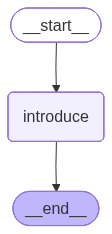

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [8]:

result = app.invoke({"name": "kamal"})
print(result)

{'name': 'kamal', 'message': 'My name is kamal.'}


In [9]:

print(result["message"])


My name is kamal.


Conditional Graph

In [10]:

from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [11]:

class AgentState(TypedDict):
    num1: int
    num2: int
    operation: str
    result: int


In [12]:
def addition(state:AgentState) -> AgentState:
    state["result"] = state["num1"] + state["num2"]
    return state

def subtraction(state:AgentState) -> AgentState:
    state["result"] = state["num1"] - state["num2"]
    return state

def multiplication(state:AgentState) -> AgentState:
    state["result"] = state["num1"] * state["num2"]
    return state

def division(state:AgentState) -> AgentState:
    state["result"] = state["num1"] / state["num2"]
    return state


def decision_node(state:AgentState) -> AgentState:
    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
    elif state["operation"] == "*":
        return "multiplication_operation"
    elif state["operation"] == "/":
        return "division_operation"

In [14]:
workflow = StateGraph(AgentState)

workflow.add_node("addition", addition)
workflow.add_node("subtraction", subtraction)
workflow.add_node("multiplication", multiplication)
workflow.add_node("division", division)
workflow.add_node("router", lambda state:state)

workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router",
    decision_node,
    {
        "addition_operation": "addition",
        "subtraction_operation": "subtraction",
        "multiplication_operation":"multiplication",
        "division_operation":"division"
    }
 )
workflow.add_edge("addition", END)
workflow.add_edge("subtraction", END)
workflow.add_edge("multiplication", END)
workflow.add_edge("division", END)

app = workflow.compile()


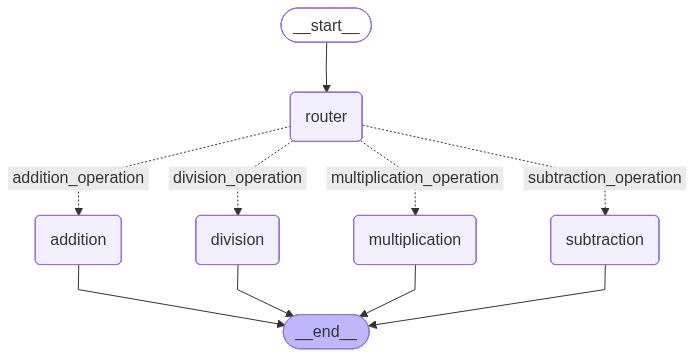

In [15]:

from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


In [16]:
result = app.invoke({"num1": 23, "num2": 10, "operation": "+"})
print(result)


{'num1': 23, 'num2': 10, 'operation': '+', 'result': 33}
